<a href="https://colab.research.google.com/github/jhonmiltonpedz/costos-marginales-sein/blob/main/notebooks/analisis_cmg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

base = "https://raw.githubusercontent.com/jhonmiltonpedz/costos-marginales-sein/main/data/"
partes = []
i = 1
while True:
    try:
        df = pd.read_excel(f"{base}cmg_parte{i}.xlsx")
    except Exception:
        break
    df.columns = ["fecha", "cmg_soles_kwh"]
    partes.append(df)
    i += 1
print(f"Partes leídas: {len(partes)}")

cmg = pd.concat(partes, ignore_index=True)
cmg["fecha"] = pd.to_datetime(cmg["fecha"], dayfirst=True)
cmg = cmg.drop_duplicates(subset="fecha").sort_values("fecha").reset_index(drop=True)
cmg["cmg_soles_mwh"] = cmg["cmg_soles_kwh"] * 1000

print(cmg["fecha"].min(), "→", cmg["fecha"].max())
print(f"Total de registros: {len(cmg)}")

por_dia = cmg.groupby(cmg["fecha"].dt.date).size()
print("Días incompletos:", (por_dia != 96).sum())

cmg.to_csv("cmg_santarosa220.csv", index=False)

Partes leídas: 24
2024-06-01 00:15:00 → 2026-06-01 00:00:00
Total de registros: 70080
Días incompletos: 2


In [2]:
cmg["fecha"] = cmg["fecha"] - pd.Timedelta(minutes=15)

por_dia = cmg.groupby(cmg["fecha"].dt.date).size()
print(cmg["fecha"].min(), "→", cmg["fecha"].max())
print("Días incompletos:", (por_dia != 96).sum())

cmg.to_csv("cmg_santarosa220.csv", index=False)

2024-06-01 00:00:00 → 2026-05-31 23:45:00
Días incompletos: 0


In [3]:
url_dem = base + "demanda_sein_2024-06_2026-05.xlsx"
dem = pd.read_excel(url_dem, header=3)

dem = dem[["FECHA", "EJECUTADO"]].rename(columns={"FECHA": "fecha", "EJECUTADO": "demanda_mw"})
dem = dem.dropna()
dem["fecha"] = pd.to_datetime(dem["fecha"], dayfirst=True)
dem["fecha"] = dem["fecha"] - pd.Timedelta(minutes=30)
dem = dem.drop_duplicates(subset="fecha").sort_values("fecha").reset_index(drop=True)

por_dia = dem.groupby(dem["fecha"].dt.date).size()
print(dem["fecha"].min(), "→", dem["fecha"].max())
print(f"Total de registros: {len(dem)}")
print("Días incompletos:", (por_dia != 48).sum())

2024-06-01 00:00:00 → 2026-05-31 23:30:00
Total de registros: 35040
Días incompletos: 0


In [4]:
cmg30 = cmg.set_index("fecha")[["cmg_soles_mwh"]].resample("30min").mean()
datos = cmg30.join(dem.set_index("fecha"), how="inner").reset_index()

print(f"Registros combinados: {len(datos)}")
print(datos.isna().sum())
datos.head()

datos.to_csv("cmg_demanda_30min.csv", index=False)

Registros combinados: 35040
fecha            0
cmg_soles_mwh    0
demanda_mw       0
dtype: int64


In [5]:
import matplotlib.pyplot as plt

datos["mes"] = datos["fecha"].dt.month
datos["temporada"] = datos["mes"].apply(lambda m: "Avenida" if m in [12, 1, 2, 3, 4, 5] else "Estiaje")

resumen = datos.groupby("temporada")[["cmg_soles_mwh", "demanda_mw"]].agg(["mean", "median"]).round(1)
resumen

cmg_soles_mwh        demanda_mw        
                   mean median       mean  median
temporada                                        
Avenida           129.0   93.2     7246.6  7307.2
Estiaje           110.5  100.4     6931.3  7045.5

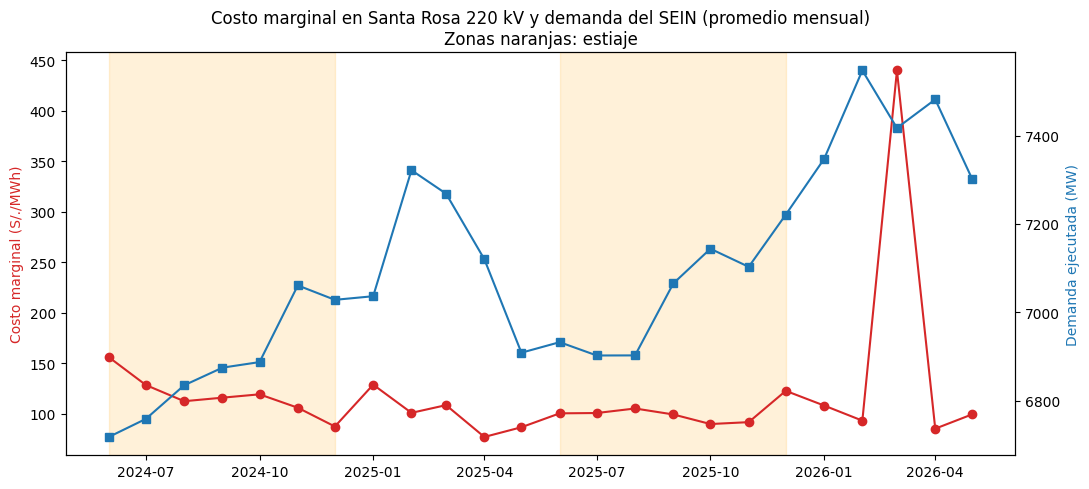

In [6]:
mensual = datos.set_index("fecha").resample("MS")[["cmg_soles_mwh", "demanda_mw"]].mean()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(mensual.index, mensual["cmg_soles_mwh"], marker="o", color="tab:red")
ax1.set_ylabel("Costo marginal (S/./MWh)", color="tab:red")

ax2 = ax1.twinx()
ax2.plot(mensual.index, mensual["demanda_mw"], marker="s", color="tab:blue")
ax2.set_ylabel("Demanda ejecutada (MW)", color="tab:blue")

for anio in [2024, 2025]:
    ax1.axvspan(pd.Timestamp(f"{anio}-06-01"), pd.Timestamp(f"{anio}-12-01"), color="orange", alpha=0.15)

ax1.set_title("Costo marginal en Santa Rosa 220 kV y demanda del SEIN (promedio mensual)\nZonas naranjas: estiaje")
fig.tight_layout()
plt.savefig("cmg_mensual.png", dpi=150)
plt.show()

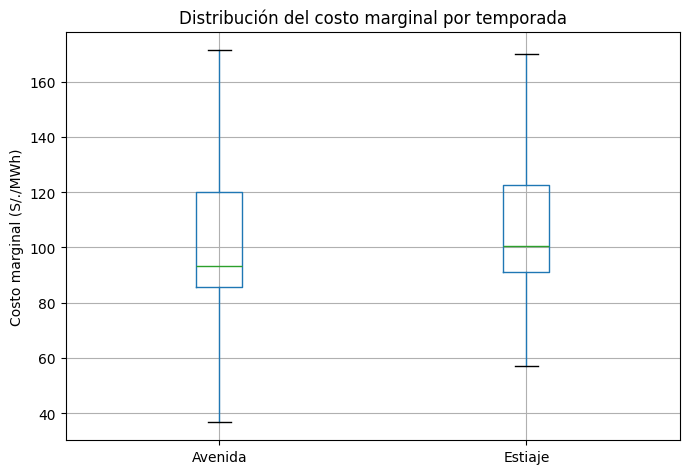

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
datos.boxplot(column="cmg_soles_mwh", by="temporada", ax=ax, showfliers=False)
ax.set_title("Distribución del costo marginal por temporada")
ax.set_xlabel("")
ax.set_ylabel("Costo marginal (S/./MWh)")
plt.suptitle("")
fig.tight_layout()
plt.savefig("cmg_temporada.png", dpi=150)
plt.show()

/tmp/ipykernel_4315/3838765834.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr = datos.groupby("temporada").apply(lambda g: g["cmg_soles_mwh"].corr(g["demanda_mw"])).round(2)


Correlación demanda vs costo marginal:
temporada
Avenida    0.15
Estiaje    0.03
dtype: float64


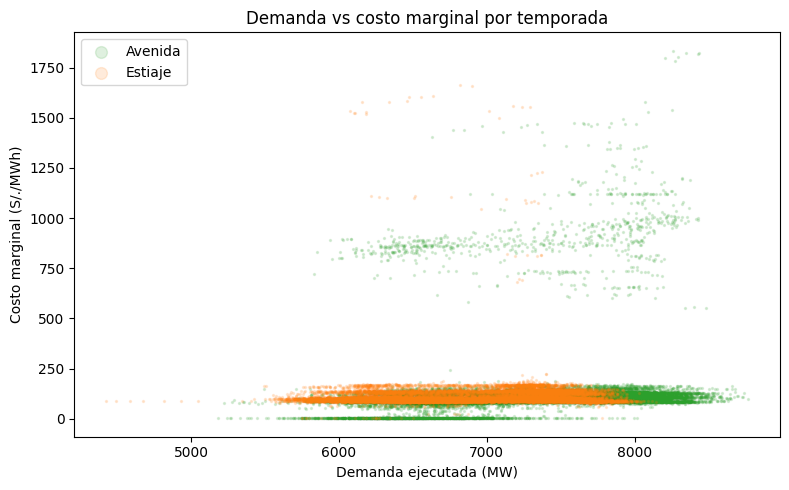

In [8]:
corr = datos.groupby("temporada").apply(lambda g: g["cmg_soles_mwh"].corr(g["demanda_mw"])).round(2)
print("Correlación demanda vs costo marginal:")
print(corr)

fig, ax = plt.subplots(figsize=(8, 5))
for temp, color in [("Avenida", "tab:green"), ("Estiaje", "tab:orange")]:
    sub = datos[datos["temporada"] == temp]
    ax.scatter(sub["demanda_mw"], sub["cmg_soles_mwh"], s=2, alpha=0.15, color=color, label=temp)
ax.set_xlabel("Demanda ejecutada (MW)")
ax.set_ylabel("Costo marginal (S/./MWh)")
ax.set_title("Demanda vs costo marginal por temporada")
ax.legend(markerscale=6)
fig.tight_layout()
plt.savefig("cmg_vs_demanda.png", dpi=150)
plt.show()

In [10]:
crisis = (datos["fecha"] >= "2026-03-01") & (datos["fecha"] < "2026-03-22")
sin_crisis = datos[~crisis]

print("SIN la crisis de Camisea:")
print(sin_crisis.groupby("temporada")["cmg_soles_mwh"].agg(["mean", "median"]).round(1))
print()
print("Correlación demanda vs costo marginal (sin crisis):")
print(sin_crisis.groupby("temporada")[["cmg_soles_mwh", "demanda_mw"]].apply(lambda g: g["cmg_soles_mwh"].corr(g["demanda_mw"])).round(2))
print()
print("Promedio durante la crisis:", round(datos.loc[crisis, "cmg_soles_mwh"].mean(), 1), "S/./MWh")
print("Intervalos con costo marginal menor a 5 S/./MWh por temporada:")
print(datos[datos["cmg_soles_mwh"] < 5].groupby("temporada").size())

SIN la crisis de Camisea:
            mean  median
temporada               
Avenida     99.8    93.0
Estiaje    110.5   100.4

Correlación demanda vs costo marginal (sin crisis):
temporada
Avenida    0.24
Estiaje    0.03
dtype: float64

Promedio durante la crisis: 605.9 S/./MWh
Intervalos con costo marginal menor a 5 S/./MWh por temporada:
temporada
Avenida    1310
Estiaje      22
dtype: int64
